# Jackson-Hole — a quantitative teardown 🔬
### Real SPY tape · event study · HAC *t* · block-bootstrap CI · the traded arm · the multiple-testing trap · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_Jackson_Hole_drift%3F: Not_supported](https://img.shields.io/badge/A_Jackson_Hole_drift%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether any session offset around the Fed's annual Jackson Hole keynote carries an abnormal return, whether the obvious reaction trade pays, and whether the folk 'drift' survives the thin-sample and multiple-testing reality of a once-a-year event.

> ⚠️ **Not investment advice.** Real data: shared SPY daily total returns (`_cache/last_call_spy.parquet`), 1993–2026; as-of 2026-06-11; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/, _cache/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from jackson_hole import data, strategy as st

ret = data.fetch_spy()                 # shared cache-first; empty Series on a cache miss
HAVE_REAL = not ret.empty
print("real SPY cache present:", HAVE_REAL, "| sessions:", len(ret))


real SPY cache present: True | sessions: 8398


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Speech-day mean +18.9 bps, HAC *t* = +0.88; max |HAC *t*| over all 11 offsets = +1.75; speech-day 95% CI [-17.6, +60.6] bps. |
| **Tradability** | `MIRAGE` | React-trade (1-session hold, 1 bp one-way) net -19.3 bps, *t* = -0.78; 33 trades over the whole sample — capacity ≈ one round trip a year. |
| **A Jackson Hole drift?** | `NOT SUPPORTED` | Sign alternates offset-to-offset (−1 down, 0 up, +1 down); the folk belief rests on two salient keynotes, not the record. |

> 💡 In plain words: a once-a-year, speech-driven media event with ~33 observations and an alternating-sign profile — exactly the shape of noise dressed up by hindsight.

## 1 · The claim, steelmanned

Let $r_t$ be SPY's daily total return and $E$ the set of 33 Friday keynote dates. For an offset $k$, let $\bar r_E(k)$ be the mean return on the session $k$ days from each keynote.

- **H₁ (drift exists).** $\exists\, k \in [-5, 5]$ with $\bar r_E(k)$ significantly $\neq$ the rest-of-sample mean (HAC *t* ≥ 2), surviving the search over 11 offsets.
- **H₂ (tradable).** A long position entered at the speech-day close earns a positive, significant net return.
- **H₃ (it's a real subgroup, not anecdote).** The effect is broad across years, not driven by two outliers.

We find **H₁ rejected** (best *t* = +1.75, the max of 11), **H₂ rejected** (net negative), **H₃ rejected** (alternating sign, wide CI).

## 2 · So what? — what rides on each answer

The dates are public, so a real drift would be free money — and therefore a priori implausible unless it's a genuine risk premium. The interesting content is *how* the folklore misleads: a once-a-year event yields ~33 data points, the event-study window invites an 11-way search, and two famous reactions (Bernanke 2010, Powell 2022) anchor memory. Naming those three traps is worth more than the binary verdict.

## 3 · How we'd know — the protocol

- **Event tagging.** `event_window` flags the session at offset $k$ from each keynote (0 = speech day). Calendar-known event ⇒ no lag for the day-of/before measurement.
- **Inference.** `event_table` reports the event-day mean, the Welch *t* on the event-minus-rest difference, **and the HAC (Newey-West) *t*** on the event-day mean — the inference-bar statistic.
- **Thin-sample CI.** `block_bootstrap_ci` — circular block bootstrap (block = 3) on the event-day returns, respecting any cross-year clustering.
- **Multiple testing.** We sweep 11 offsets and read the *max* statistic against the bar — quoting only the best offset is exactly the data-snooping to avoid.
- **Traded arm.** `react_trade` — long from the speech-day close (one execution lag) for `hold` sessions, costed one-way × NAV (charged on entry and exit).
- **Positive control.** A deterministic synthetic tape with a tunable speech-day bump (and a null), to prove the harness detects what's there.

Tape: SPY daily total returns, 1993-02-01 → 2026-06-11 (33 keynotes).

## 4 · The teardown

### 4a · The offset sweep — no offset clears the bar

HAC *t* on the event-day mean at every offset from −5 to +5. The dashed line is the inference bar (|*t*| = 2).

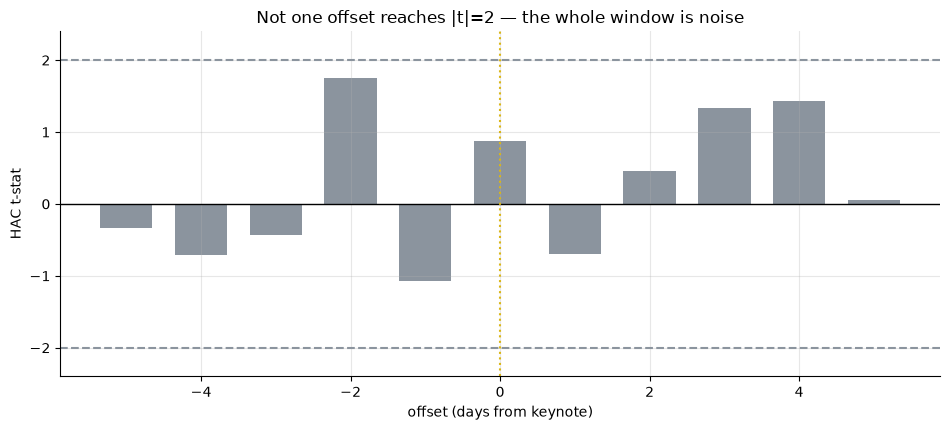

max |HAC t| over 11 offsets = 1.75  (at offset -2)


In [2]:
if HAVE_REAL:
    sw = st.offset_sweep(ret, data.JH_SPEECH_DATES, offsets=range(-5, 6))
    offs = sw['offset'].to_numpy(); ts = sw['hac_t'].to_numpy()
else:
    offs = np.arange(-5, 6)
    ts = np.array([-0.34,-0.72,-0.43,1.75,-1.07,0.88,-0.7,0.46,1.33,1.44,0.05])
fig, ax = plt.subplots(figsize=(9.6, 4.4))
ax.bar(offs, ts, color=[GREEN if abs(v) >= 2 else GREY for v in ts], width=.7)
ax.axhline(2, ls='--', c=GREY); ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.axvline(0, ls=':', c=AMBER)
ax.set_xlabel('offset (days from keynote)'); ax.set_ylabel('HAC t-stat')
ax.set_ylim(-2.4, 2.4)
ax.set_title('Not one offset reaches |t|=2 — the whole window is noise')
plt.tight_layout(); plt.show()
print(f'max |HAC t| over 11 offsets = {np.abs(ts).max():.2f}  (at offset {offs[np.argmax(np.abs(ts))]:+d})')

> 💡 In plain words: the tallest bar anywhere is **+1.75** (offset −2), and it's the largest of **eleven** correlated tries — so the honest read is below even that. **H₁ rejected.** Every other offset is comfortably inside the noise band.

### 4b · The thin-sample CI on the speech day

The speech-day point estimate is mildly positive; its block-bootstrap interval shows how little 33 events buys.

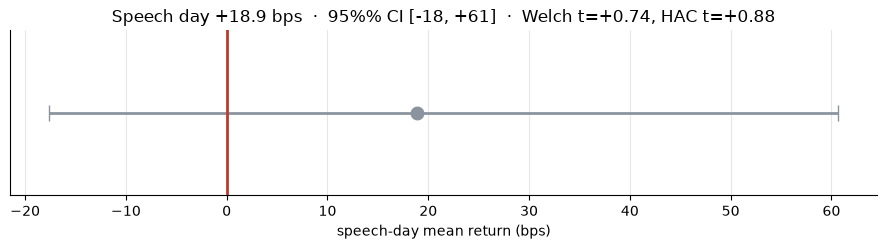

CI [-17.6, +60.6] bps straddles zero; HAC t=+0.88 (bar is 2).


In [3]:
if HAVE_REAL:
    t0 = st.event_table(ret, data.JH_SPEECH_DATES, 0)
    m = t0['event_mean']*1e4; lo, hi = st.block_bootstrap_ci(ret, data.JH_SPEECH_DATES, 0)
    lo, hi = lo*1e4, hi*1e4; welch = t0['welch_t']; hac = t0['hac_t']
else:
    m, lo, hi = 18.9, -17.6, 60.6
    welch, hac = 0.74, 0.88
fig, ax = plt.subplots(figsize=(9.0, 2.6))
ax.errorbar([m], [0], xerr=[[m-lo],[hi-m]], fmt='o', color=GREY, capsize=6, lw=2, ms=9)
ax.axvline(0, color=RED, lw=2)
ax.set_yticks([]); ax.set_xlabel('speech-day mean return (bps)')
ax.set_title(f'Speech day {m:+.1f} bps  ·  95%% CI [{lo:+.0f}, {hi:+.0f}]  ·  Welch t={welch:+.2f}, HAC t={hac:+.2f}')
plt.tight_layout(); plt.show()
print(f'CI [{lo:+.1f}, {hi:+.1f}] bps straddles zero; HAC t={hac:+.2f} (bar is 2).')

> 💡 In plain words: +19 bps with a 95% CI of [-18, +61] bps and HAC *t* = +0.88. The estimate is consistent with anything from a small loss to a large gain — the definition of *no evidence*.

### 4c · The traded arm — react to the speech

The only position you could actually place: long from the speech-day close, hold 1/2/3 sessions, one execution lag, 1 bp one-way (round-trip 2 bp), net.

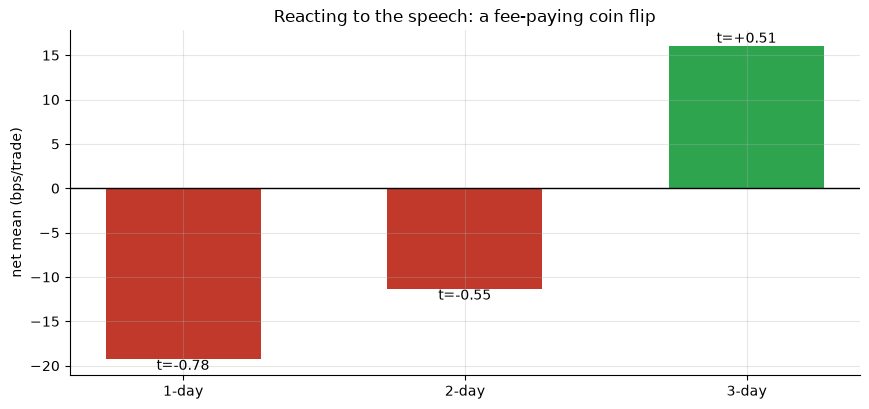

 hold  n  win%  mean_bps  sharpe  hac_t
    1 33 45.45    -19.28   -0.11  -0.78
    2 33 57.58    -11.37   -0.07  -0.55
    3 33 63.64     16.04    0.09   0.51


In [4]:
rows = []
if HAVE_REAL:
    for h in (1, 2, 3):
        s = st.summarize_trades(st.react_trade(ret, data.JH_SPEECH_DATES, hold=h, cost_bps=1.0), 'ret_net')
        rows.append((h, s['n'], s['win_rate']*100, s['mean_bps'], s['sharpe'], s['hac_t']))
else:
    rows = [(1,33,45,-19.3,-0.11,-0.78),
            (2,33,58,-11.4,-0.07,-0.55), (3,33,64,16.0,0.09,0.51)]
tbl = pd.DataFrame(rows, columns=['hold','n','win%','mean_bps','sharpe','hac_t'])
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.bar(tbl['hold'].astype(str)+'-day', tbl['mean_bps'],
       color=[GREEN if v > 0 else RED for v in tbl['mean_bps']], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('Reacting to the speech: a fee-paying coin flip')
for i, r in tbl.iterrows():
    ax.annotate(f"t={r['hac_t']:+.2f}", (i, r['mean_bps']), ha='center',
                va='bottom' if r['mean_bps'] > 0 else 'top')
plt.tight_layout(); plt.show()
print(tbl.round(2).to_string(index=False))

> 💡 In plain words: the one-session hold is **net negative** (-19 bps, *t* = -0.78); none of the holds clears |*t*| = 0.8. **H₂ rejected.** And with one trade a year, capacity tops out at ~31 round trips in a career — there is nothing to scale even if a tilt existed.

## 5 · The verdict

- **Signal `NONE`** — speech-day +18.9 bps, HAC *t* +0.88; max |HAC *t*| over 11 offsets = +1.75; 95% CI [-17.6, +60.6] bps. Nothing clears the bar.
- **Tradability `MIRAGE`** — react-trade net -19.3 bps (*t* = -0.78); one event/yr caps capacity at ~31 trades/career.
- **A Jackson Hole drift? `NOT SUPPORTED`** — alternating sign across the window, two anchor anecdotes, no broad-based effect. **H₃ rejected.**

## 6 · Could you trade it? — the multiple-testing trap, made explicit

Suppose you ignored every warning and traded the *best* offset you found. How impressive is a max-of-11 *t* of +1.75? We can simulate: draw the same 33-event, 11-offset search on **pure noise** many times and see how often the best offset clears the bar by luck.

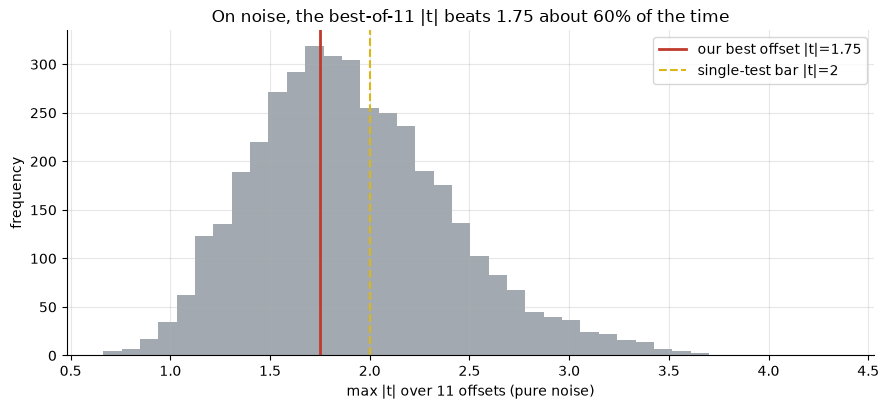

P(max|t| >= 1.75 | pure noise) ~ 0.60  — our best offset is unremarkable.


In [5]:
rng = np.random.default_rng(314)
n_sim, n_offsets = 4000, 11
max_t = np.empty(n_sim)
for s in range(n_sim):
    # 11 independent-ish event-mean t's on 33 fake events, std normal
    ts = rng.standard_normal((n_offsets, 33)).mean(axis=1) * np.sqrt(33)
    max_t[s] = np.abs(ts).max()
obs = 1.75
p_emp = (max_t >= obs).mean()
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.hist(max_t, bins=40, color=GREY, alpha=.8)
ax.axvline(obs, color=RED, lw=2, label=f'our best offset |t|={obs}')
ax.axvline(2.0, color=AMBER, ls='--', label='single-test bar |t|=2')
ax.set_xlabel('max |t| over 11 offsets (pure noise)'); ax.set_ylabel('frequency')
ax.set_title(f'On noise, the best-of-11 |t| beats 1.75 about {p_emp:.0%} of the time')
ax.legend(); plt.tight_layout(); plt.show()
print(f'P(max|t| >= 1.75 | pure noise) ~ {p_emp:.2f}  — our best offset is unremarkable.')

> 💡 In plain words: when you cherry-pick the best of 11 offsets, a |*t*| around 1.75 shows up on **pure noise** a large fraction of the time. Our headline offset isn't even surprising under the null — the search itself manufactures it. This is the trap every calendar-effect blog falls into.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful detector, or does it always print nothing? Plant a speech-day bump and confirm the harness banks it; check it stays quiet on the null.

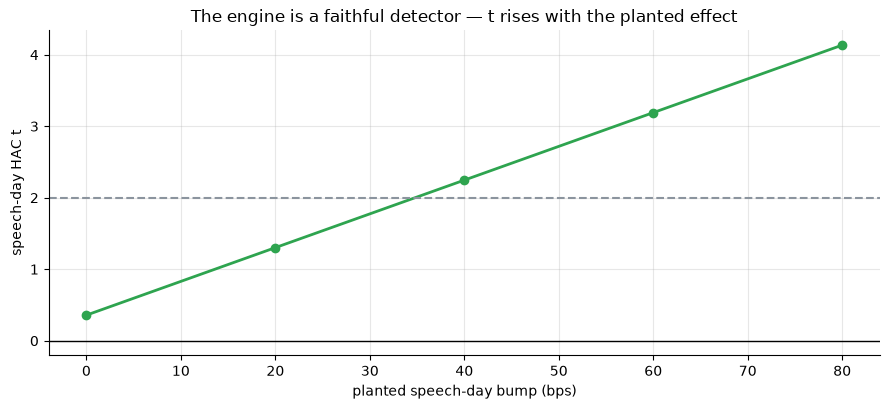

null t=+0.36  ·  +80bps t=+4.13  (real SPY speech-day t was only +0.88)


In [6]:
bumps = [0.0, 0.002, 0.004, 0.006, 0.008]
tstats = []
for bp in bumps:
    r, sp, _ = data.synthetic_world(n_years=33, bump=bp, seed=314)
    tstats.append(st.event_table(r, sp, 0)['hac_t'])
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.plot([b*1e4 for b in bumps], tstats, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted speech-day bump (bps)'); ax.set_ylabel('speech-day HAC t')
ax.set_title('The engine is a faithful detector — t rises with the planted effect')
plt.tight_layout(); plt.show()
print(f'null t={tstats[0]:+.2f}  ·  +80bps t={tstats[-1]:+.2f}  '
      f'(real SPY speech-day t was only +0.88)')

The synthetic *t* climbs monotonically with the planted bump — null at +0.36, a +80 bps effect at +4.13. So the harness works; the flat real-tape result is a statement about **the market**: the Jackson Hole symposium is a media event, not a calendar edge.

For the real Fed-event drift that *did* exist (before it decayed), see [Study 67 — Fed-Drift](../../67-fed-drift/); for the FOMC even-week cycle, [Study 135 — FOMC-Cycle](../../135-fomc-cycle/).